# 202 — multimodalidad · bloque conjunto ξ₁..ξ₄ · E_03 convergencia

Diagnósticos sobre cantidades invariantes a la permutación de etiquetas (log-verosimilitud, error in-sample, átomos activos, entropía, μ, g, π_j). No toca el bloque de prueba.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RAIZ = Path.cwd().resolve().parent
sys.path.insert(0, str(RAIZ))
from mv_psbp.pipeline import *
from mv_psbp import datos, convergencia, evaluacion, comparacion
pd.set_option("display.width", 200)


In [2]:
# [CONFIG]
ESC       = "202"           # escenario de la corrida viva (se lee de fuera, no se modifica)
EID       = "mvb_escenario_202_chungEscX_1_r01_K10"
EID_MV    = "mv_escenario_202_chungEscX_1_r01_K10"       # conjunto completo (K coordenadas), tercer competidor en E_05
DOMINIO   = "simulaciones"
BLOQUE    = (0, 1, 2, 3)         # coordenadas del bloque conjunto (scores activos del generador)
N_CHAINS  = 3
LIMPIAR   = False


,submodelo,variable,rhat,ess_min,geweke_max,media,sd,converge
0,bloque,loglik,2.563,23.386,1.959,-1029.557,28.953,False
1,bloque,mse_in,2.252,68.997,1.567,0.598,0.006,False
2,bloque,N_activos,1.019,54.941,1.857,6.685,3.639,False
3,bloque,entropia,1.872,40.136,2.159,0.741,0.092,False
4,bloque,mu,1.009,48.756,2.328,1.312,0.484,False
...,...,...,...,...,...,...,...,...
69,uni_10,entropia,1.162,5.727,4.401,0.415,0.336,False
70,uni_10,mu,1.062,11.479,9.125,0.432,0.665,False
71,uni_10,g,1.000,61.557,2.850,2.625,2.010,False
72,uni_10,pi[coef_10_lag1],1.026,24.165,4.773,0.625,0.301,False


{'gamma_rango_loglik_medio': 1725.3214471653805, 'gamma_no_finito': 0, 'min_por_iter': 0.5970027058992281}


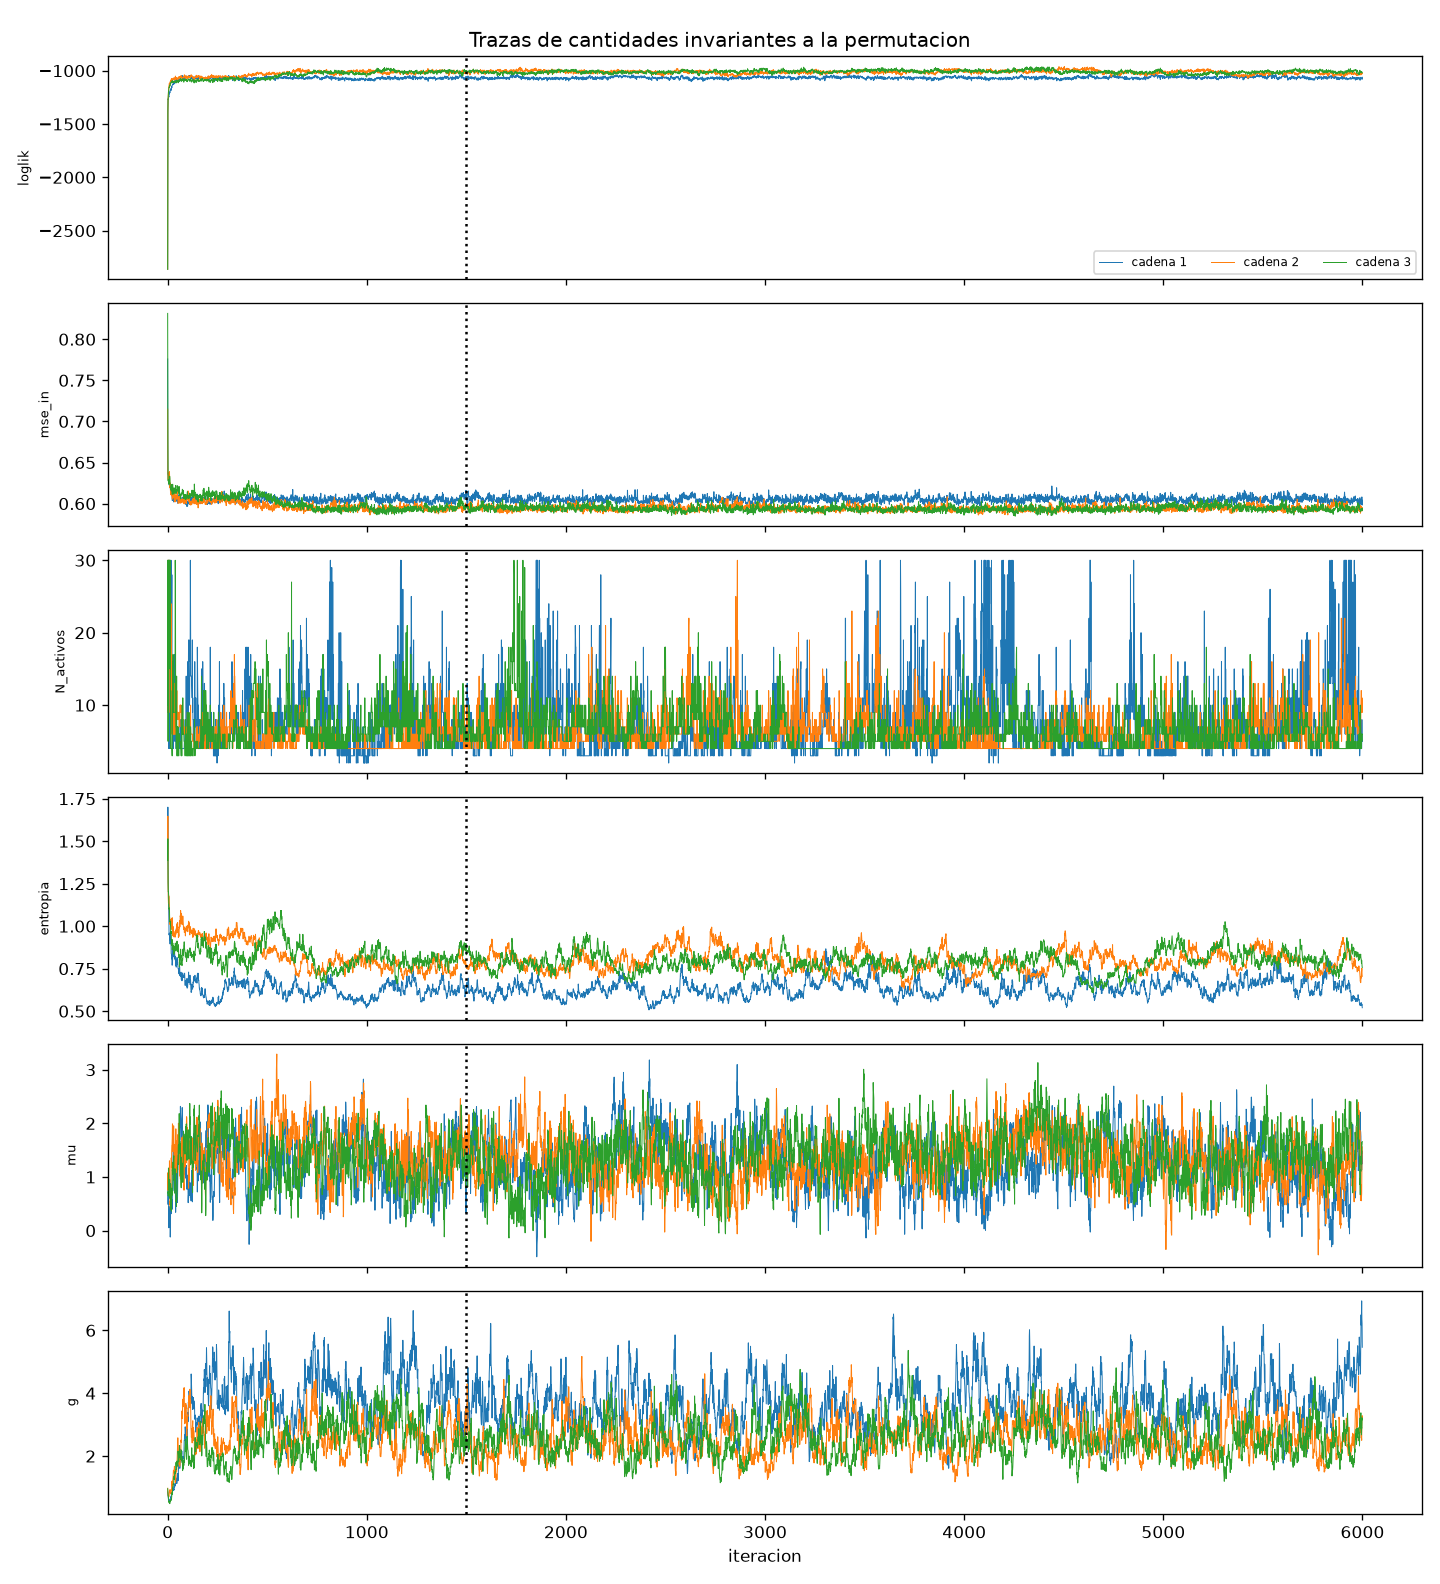

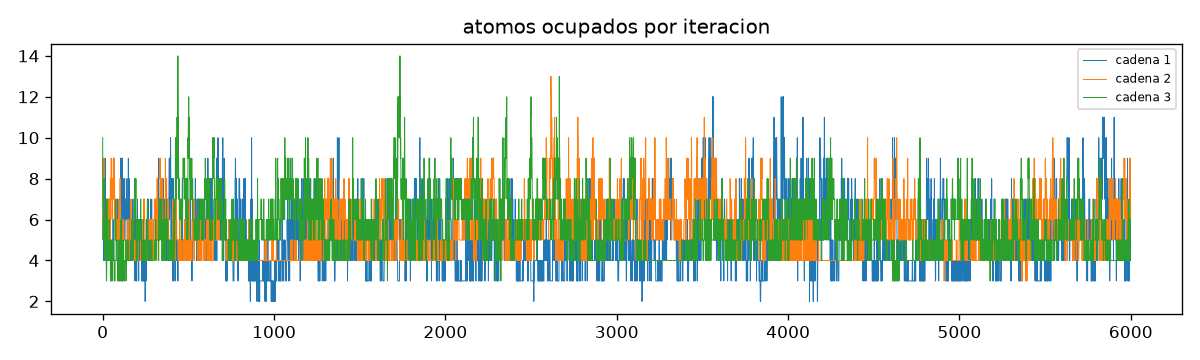

In [3]:
paths = paths_de(EID, DOMINIO)
c = convergencia.paso03(paths, N_CHAINS)
display(c["diagnosticos"].round(3)); print(c["extra"])
display(Image(filename=str(paths["out_report"] / "40_trazas.png")))
display(Image(filename=str(paths["out_report"] / "44_ocupacion.png")))

In [4]:
display(c["pip"].round(3))
pp = c["pip"].set_index("predictor")
ax = pp[["pi_j", "frac_atomos_ocupados_con_j"]].plot.bar(figsize=(12, 3.5)); ax.set_title("inclusión por predictor"); plt.show()

,submodelo,predictor,pi_j,frac_atomos_ocupados_con_j
0,bloque,coef_1_lag1,0.869,0.943
1,bloque,coef_2_lag1,0.848,0.906
2,bloque,coef_3_lag1,0.624,0.646
3,bloque,coef_4_lag1,0.502,0.494
4,bloque,coef_5_lag1,0.055,0.029
5,bloque,coef_6_lag1,0.045,0.022
6,bloque,coef_7_lag1,0.044,0.021
7,bloque,coef_8_lag1,0.049,0.026
8,bloque,coef_9_lag1,0.048,0.024
9,bloque,coef_10_lag1,0.050,0.025


C:\Users\56jua\AppData\Local\Temp\ipykernel_47668\767643145.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax = pp[["pi_j", "frac_atomos_ocupados_con_j"]].plot.bar(figsize=(12, 3.5)); ax.set_title("inclusión por predictor"); plt.show()
